### Import data analysis libraries

In [157]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lasio as ls
import plotly.express as px # type: ignore

### Import Supervised Machine Learning libraries

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
from xgboost import XGBRegressor

### Import Unsupervised Machine Learning libraries

In [159]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Data Preparation

In [160]:
las_1 = ls.read("Data/5002320003.las")
las_2 = ls.read("Data/5002320005.las")
las_3 = ls.read("Data/5002320007.las")
las_4 = ls.read("Data/5002320008.las")
las_5 = ls.read("Data/5002320009.las")
las_6 = ls.read("Data/5002320011.las")
las_7 = ls.read("Data/5002320012.las")
las_8 = ls.read("Data/5002320014.las")
las_9 = ls.read("Data/5002320016.las")
las_10 = ls.read("Data/5002320018.las")
las_11 = ls.read("Data/5002320019.las")

In [161]:
# Print the curves for each las file
print(las_1.curves)
print(las_2.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
ASN       OHMM         3            
ILD       OHMM         4            
CILD      MMHO         5            
CALI      IN           6            
GR        GAPI         7            
DRHO      G/C3         8            
RHOB      G/C3         9            
DT        US/F         10           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
GR        GAPI         3            
RHOB      G/C3         4            
NPHI      %            5            
DPHI      %            6            
SP        MV           7            
LL8       OHMM         8            
ILD       OHMM         9            
CILD      MMHO         10           
DT        US/F         11           


In [162]:
print(las_3.curves)
print(las_4.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
ILD       OHMM         3            
LL8       OHMM         4            
ILM       OHMM         5            
RHOB      G/C3         6            
DRHO      G/C3         7            
CALI      IN           8            
GR        GAPI         9            
NPHI      %            10           
DT        US/F         11           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
ILD       OHMM         3            
LL8       OHMM         4            
CILD      MMHO         5            
ILM       OHMM         6            
GR        GAPI         7            
CALI      IN           8            
DRHO      G/C3         9            
RHOB      G/C3         10           
NPHI      %            11           
DPHI      %            12           
D

In [163]:
print(las_5.curves)
print(las_6.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
LLS       OHMM         2            
LLD       OHMM         3            
SP        MV           4            
ILD       OHMM         5            
ILM       OHMM         6            
LL8       OHMM         7            
CALI      IN           8            
GR        GAPI         9            
NPHI      %            10           
DPHI      %            11           
RHOB      G/C3         12           
DRHO      G/C3         13           
DT        US/F         14           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
GR        GAPI         3            
NPHI      %            4            
RHOB      G/C3         5            
DRHO      G/C3         6            
DT        US/F         7            
SP        MV           8            
ILD       OHMM         9            
I

In [164]:
print(las_7.curves)
print(las_8.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
GR        GAPI         2            
CALI      IN           3            
RHOB      G/C3         4            
DRHO      G/C3         5            
NPHI      %            6            
DT        US/F         7            
SP        MV           8            
ILD       OHMM         9            
ILM       OHMM         10           
LL8       OHMM         11           
LLD       OHMM         12           
LLS       OHMM         13           
MSFL      OHMM         14           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
SP        MV           2            
LLD       OHMM         3            
LLS       OHMM         4            
MSFL      OHMM         5            
CALI      IN           6            
RHOB      G/C3         7            
DRHO      G/C3         8            
NPHI      %            9            
G

In [165]:
print(las_9.curves)
print(las_10.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
GR        GAPI         3            
RHOB      G/C3         4            
DRHO      G/C3         5            
NPHI      %            6            
DT        US/F         7            
SP        MV           8            
ILD       OHMM         9            
ILM       OHMM         10           
SFL       OHMM         11           
LLD       OHMM         12           
LLS       OHMM         13           
MSFL      OHMM         14           
Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
GR        GAPI         2            
CALI      IN           3            
RHOB      G/C3         4            
DRHO      G/C3         5            
NPHI      %            6            
DT        US/F         7            
SP        MV           8            
LLS       OHMM         9            
L

In [166]:
print(las_11.curves)

Mnemonic  Unit  Value  Description  
--------  ----  -----  -----------  
DEPT      F            1  DEPTH     
CALI      IN           2            
DRHO      G/C3         3            
RHOB      G/C3         4            
NPHI      %            5            
DT        US/F         6            
GR        GAPI         7            
SP        MV           8            
MSFL      OHMM         9            
LLS       OHMM         10           
LLD       OHMM         11           


In [167]:
# Convert each las file to a DataFrame
las_1_df = las_1.df()
las_2_df = las_2.df()
las_3_df = las_3.df()
las_4_df = las_4.df()
las_5_df = las_5.df()
las_6_df = las_6.df()
las_7_df = las_7.df()
las_8_df = las_8.df()
las_9_df = las_9.df()
las_10_df = las_10.df()
las_11_df = las_11.df()

In [168]:
las_1_df.head()

,SP,ASN,ILD,CILD,CALI,GR,DRHO,RHOB,DT
DEPT,,,,,,,,,
1088.0,NaN,NaN,NaN,NaN,NaN,49.9702,NaN,NaN,NaN
1088.5,NaN,NaN,NaN,NaN,NaN,50.7592,NaN,NaN,NaN
1089.0,NaN,NaN,NaN,NaN,NaN,52.0155,NaN,NaN,NaN
1089.5,NaN,NaN,NaN,NaN,NaN,52.2536,NaN,NaN,NaN
1090.0,NaN,NaN,NaN,NaN,NaN,52.2993,NaN,NaN,NaN


In [169]:
# Reset the index for each DataFrame
las_1_df = las_1_df.reset_index()
las_2_df = las_2_df.reset_index()
las_3_df = las_3_df.reset_index()
las_4_df = las_4_df.reset_index()
las_5_df = las_5_df.reset_index()
las_6_df = las_6_df.reset_index()
las_7_df = las_7_df.reset_index()
las_8_df = las_8_df.reset_index()
las_9_df = las_9_df.reset_index()
las_10_df = las_10_df.reset_index()
las_11_df = las_11_df.reset_index()

In [170]:
las_1_df.head()

,DEPT,SP,ASN,ILD,CILD,CALI,GR,DRHO,RHOB,DT
0,1088.0,NaN,NaN,NaN,NaN,NaN,49.9702,NaN,NaN,NaN
1,1088.5,NaN,NaN,NaN,NaN,NaN,50.7592,NaN,NaN,NaN
2,1089.0,NaN,NaN,NaN,NaN,NaN,52.0155,NaN,NaN,NaN
3,1089.5,NaN,NaN,NaN,NaN,NaN,52.2536,NaN,NaN,NaN
4,1090.0,NaN,NaN,NaN,NaN,NaN,52.2993,NaN,NaN,NaN


**Standardize Column Names**: Rename shallow resistivity columns (LL8, LLS, etc.) to "RS" and deep resistivity columns (ILD, LLD, etc.) to "Deep_RS".

**Select Common Columns**: Ensure each DataFrame has the required columns (DEPT, NPHI, SP, DT, GR, CALI, RHOB, Deep_RS, and RS). If a DataFrame lacks any of these columns, we’ll remove it from the collection.

We only want to keep the columns/logs that are common among the dataframes.

In [171]:
# List of dataframes to process
dfs = [las_1_df, las_2_df, las_3_df, las_4_df, las_5_df, las_6_df, las_7_df, las_8_df, las_9_df, las_10_df, las_11_df]

# Standardized column names
required_columns = ["DEPT", "NPHI", "SP", "DT", "GR", "CALI", "RHOB", "Deep_RS", "RS"]

# Lists to track processed and removed DataFrames
processed_dfs = []
removed_dfs = []

for i, df in enumerate(dfs):
    # Standardize column names for shallow and deep resistivity
    df = df.rename(columns={
        "LL8": "RS", "LLS": "RS", "MSFL": "RS",
        "ILD": "Deep_RS", "LLD": "Deep_RS", "ILM": "Deep_RS"
    })

    # Check if all required columns are present
    if all(col in df.columns for col in required_columns):
        # Keep only the required columns
        df = df[required_columns]
        processed_dfs.append(df)
    else:
        # Track index of removed DataFrame
        removed_dfs.append(f"las_{i+1}_df")

# Display results
print("DataFrames retained:", [f"las_{i+1}_df" for i in range(len(processed_dfs))])
print("DataFrames removed:", removed_dfs)

DataFrames retained: ['las_1_df', 'las_2_df', 'las_3_df', 'las_4_df', 'las_5_df', 'las_6_df', 'las_7_df', 'las_8_df', 'las_9_df', 'las_10_df']
DataFrames removed: ['las_1_df']


Only **las_1_df** was removed so we'll have a list (processed_dfs) with 10 dataframes, being **processed_df[0] = las_2_df** (filtered) and so on.

In [172]:
processed_dfs[1].head()

,DEPT,NPHI,SP,DT,GR,CALI,RHOB,Deep_RS,Deep_RS,RS
0,151.0,NaN,NaN,149.9976,NaN,13.7672,NaN,NaN,NaN,NaN
1,151.5,NaN,NaN,149.9864,NaN,14.1439,NaN,NaN,NaN,NaN
2,152.0,NaN,-35.9583,149.9753,NaN,14.1713,NaN,3.9695,NaN,7.4901
3,152.5,NaN,-36.5363,149.9641,NaN,14.1778,NaN,2.8051,NaN,7.3950
4,153.0,NaN,-37.0716,149.9529,NaN,14.1762,NaN,2.1887,NaN,7.2999


In [173]:
# Initialize an empty list to store each DataFrame with its source column added
df_list = []

for i, df in enumerate(processed_dfs, start=2):
    # Check for and remove duplicate columns, if any
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Add the source column to identify the origin DataFrame
    df['source'] = f"las_{i}_df"
    df_list.append(df)

# Concatenate all DataFrames in df_list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)


In [174]:
combined_df

,DEPT,NPHI,SP,DT,GR,CALI,RHOB,Deep_RS,RS,source
0,1260.0,NaN,NaN,NaN,47.5286,NaN,NaN,NaN,NaN,las_2_df
1,1260.5,NaN,NaN,NaN,47.7171,NaN,NaN,NaN,NaN,las_2_df
2,1261.0,NaN,NaN,NaN,47.8198,NaN,NaN,NaN,NaN,las_2_df
3,1261.5,NaN,NaN,NaN,47.6691,NaN,NaN,NaN,NaN,las_2_df
4,1262.0,NaN,NaN,NaN,47.9667,NaN,NaN,NaN,NaN,las_2_df
...,...,...,...,...,...,...,...,...,...,...
54631,4350.0,NaN,-21.2292,NaN,NaN,8.1459,2.4535,14.1724,11.3857,las_11_df
54632,4350.5,NaN,-20.0351,NaN,NaN,NaN,2.4231,14.1607,NaN,las_11_df
54633,4351.0,NaN,-18.6172,NaN,NaN,NaN,2.4156,14.1491,NaN,las_11_df
54634,4351.5,NaN,-19.6531,NaN,NaN,NaN,2.3989,14.1374,NaN,las_11_df


<Axes: >

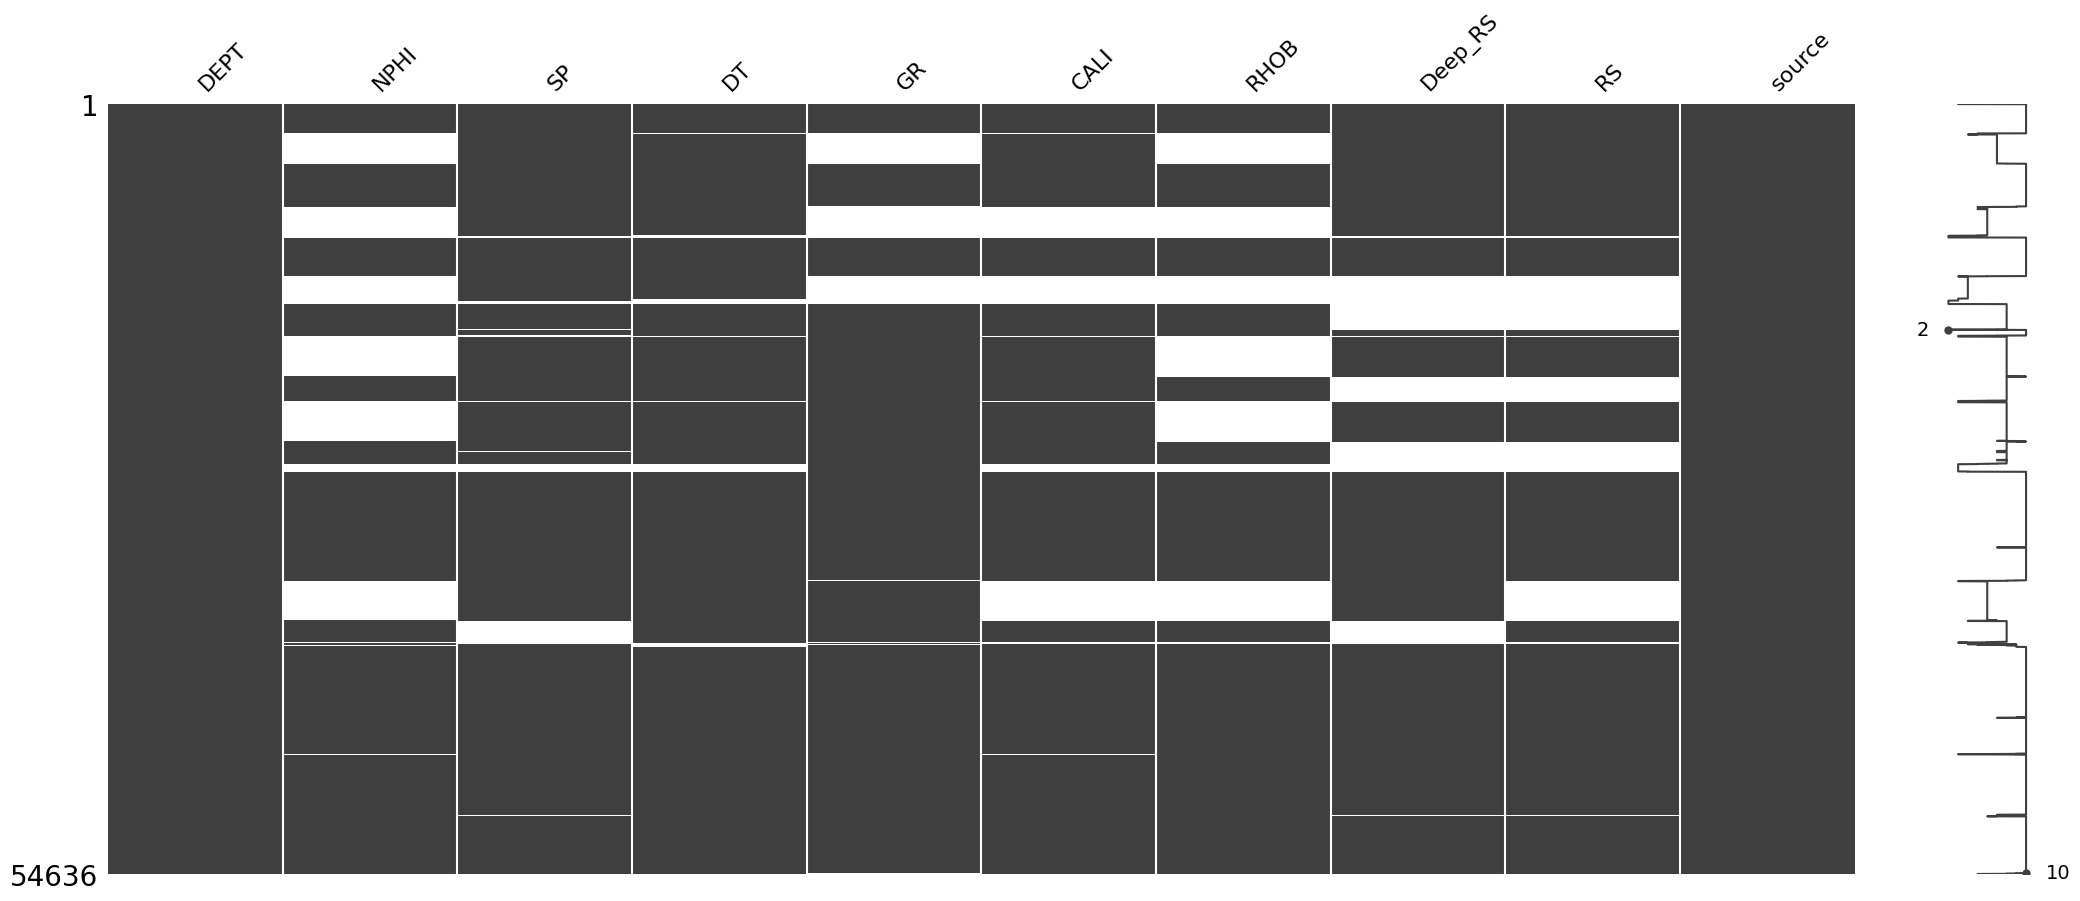

In [175]:
import missingno as msno

msno.matrix(combined_df)

We must have well logs data for every row, so NaN values must be filled or removed. Since there are over 50000 rows, we can just use **dropna**

In [176]:
combined_df.dropna(inplace=True)

<Axes: >

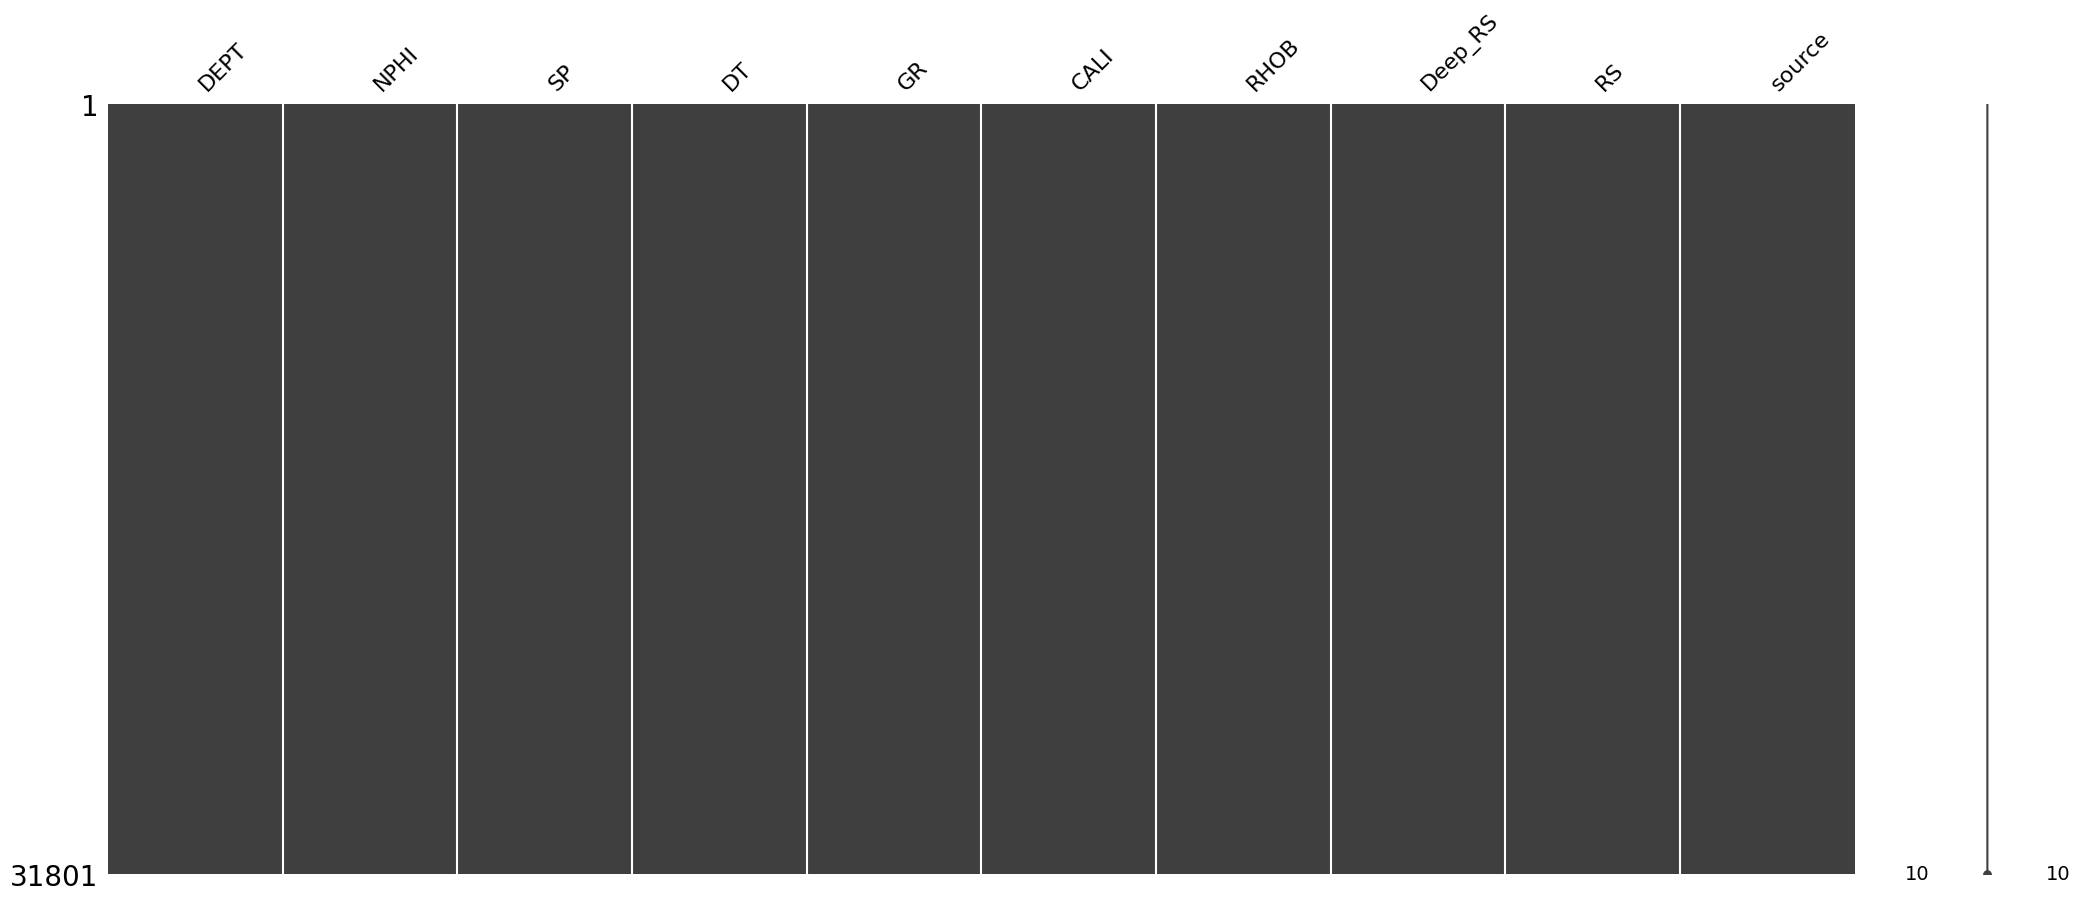

In [177]:
msno.matrix(combined_df)

**Note**: it's important to see which depth ranges don't have data now (differences over 1ft)

In [178]:
# Initialize a dictionary to store depths and differences for each source
depths_with_diff = {}

# Iterate over each unique source in the combined DataFrame
for source in combined_df['source'].unique():
    # Filter the DataFrame for the current source
    source_df = combined_df[combined_df['source'] == source]
    
    # Calculate the difference in DEPT between consecutive rows
    dept_diff = source_df['DEPT'].diff().abs()
    
    # Find the indices where the difference is 1 or more
    indices = source_df[dept_diff >= 1].index
    
    # Store the depths and their differences for the current source
    if not indices.empty:  # Check if there are any valid indices
        depths_with_diff[source] = pd.DataFrame({
            'Depth': source_df.loc[indices, 'DEPT'],
            'Difference': dept_diff[indices]
        })

# Display the results for each non-empty source
for source, data in depths_with_diff.items():
    if not data.empty:  # Ensure the DataFrame is not empty before printing
        print(f"Source: {source}, Depths and their differences:\n{data}\n")

Source: las_8_df, Depths and their differences:
        Depth  Difference
31466  2977.0         4.0

Source: las_10_df, Depths and their differences:
        Depth  Difference
43542  2708.0         2.0
43556  2715.0         1.0

Source: las_11_df, Depths and their differences:
        Depth  Difference
50547  2308.0        60.0



las_11 has a gap of 60 ft (120 data points as the interval is 0.5). However, we have enought data from other wells overall.

In [179]:
combined_df.columns

Index(['DEPT', 'NPHI', 'SP', 'DT', 'GR', 'CALI', 'RHOB', 'Deep_RS', 'RS',
       'source'],
      dtype='object')

In [180]:
# Function to adjust the title to fit in the column width
def adjust_title(ax, title):
    ax.set_title("\n".join(title.split(" ")))

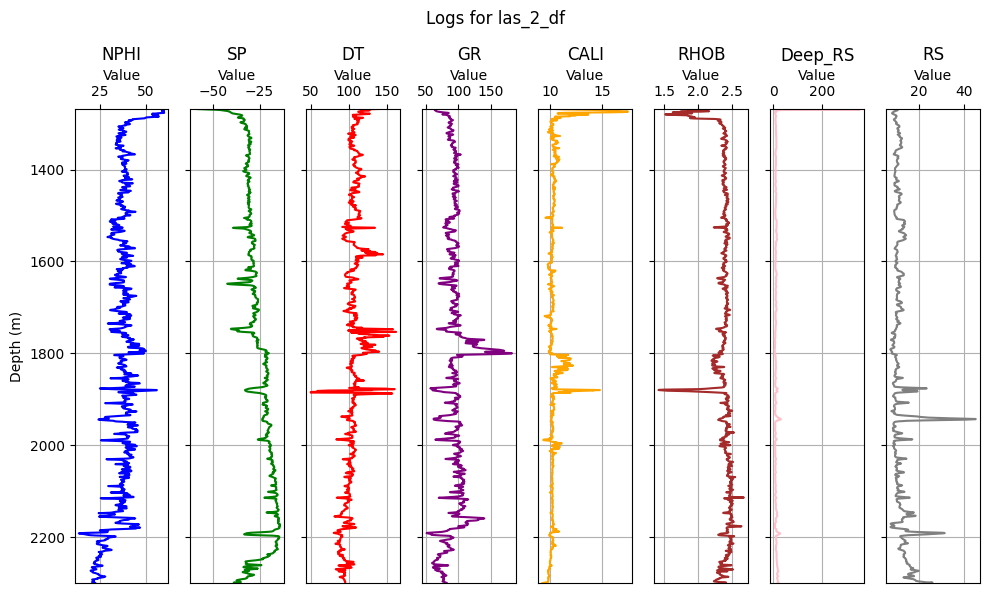

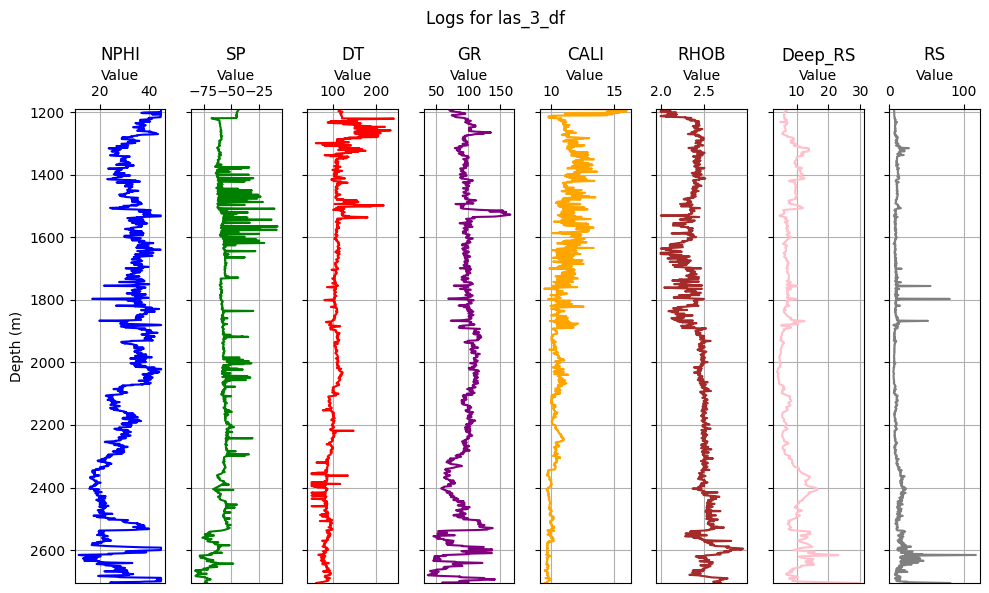

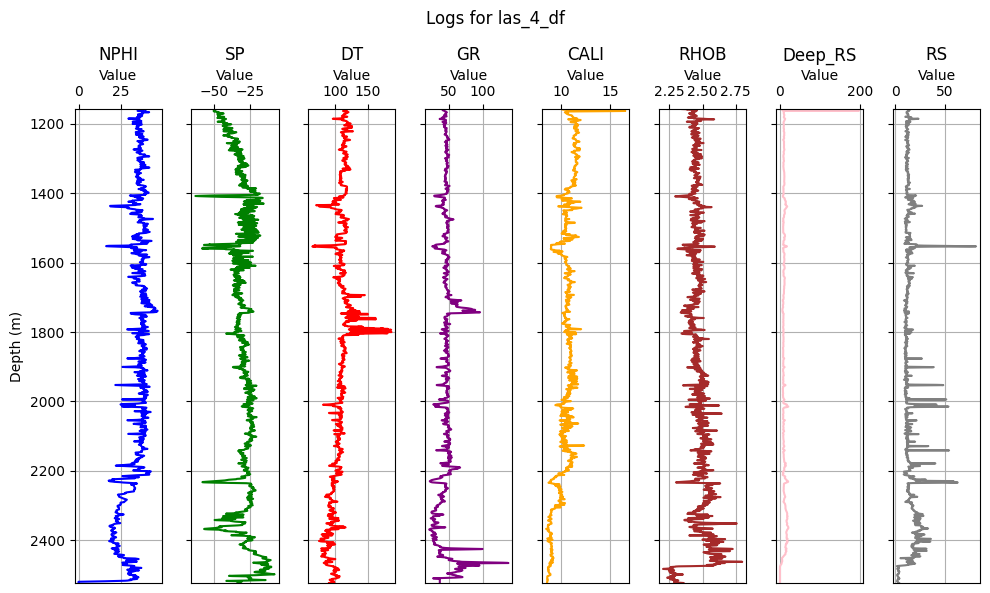

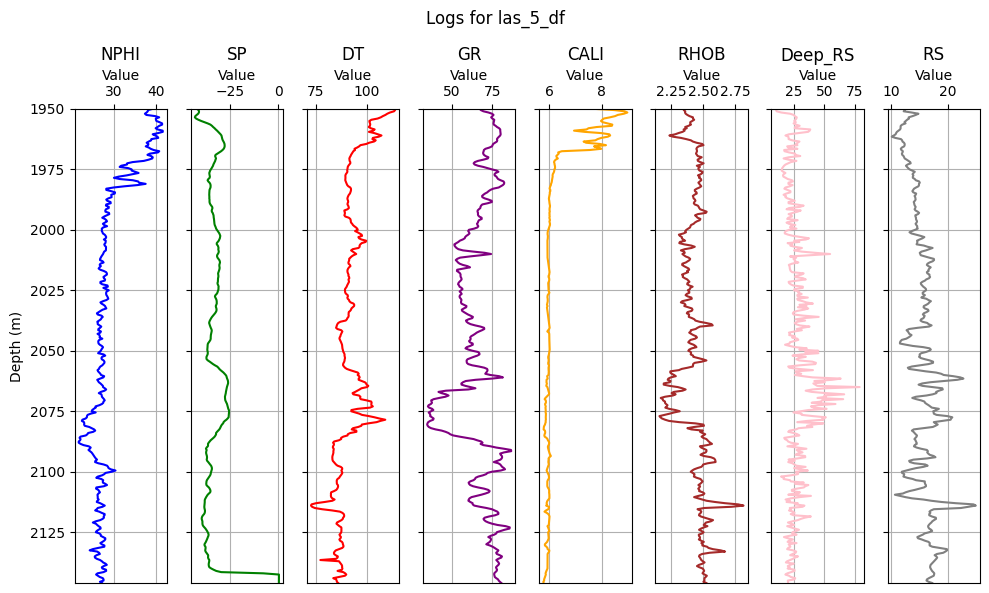

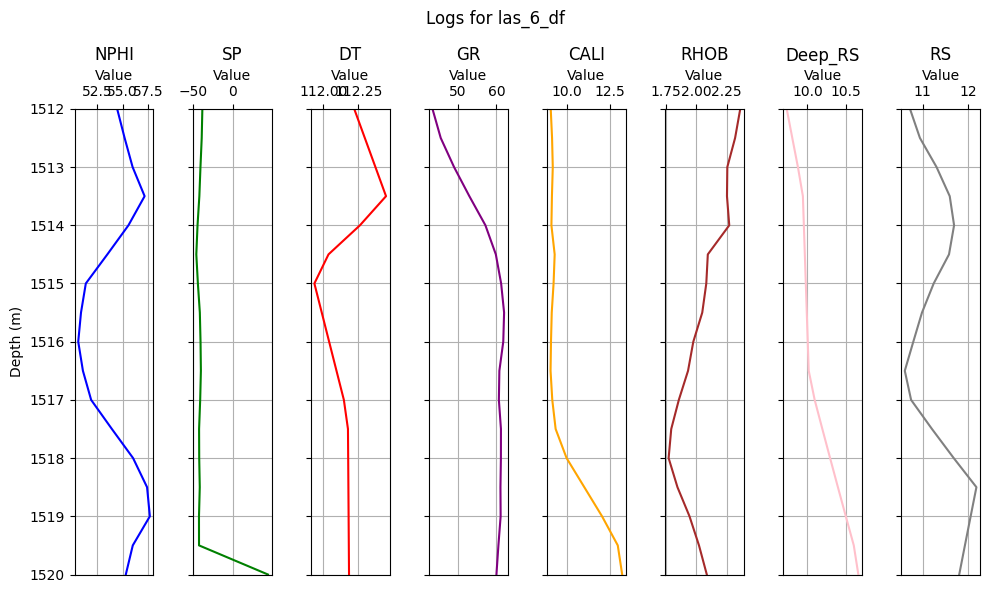

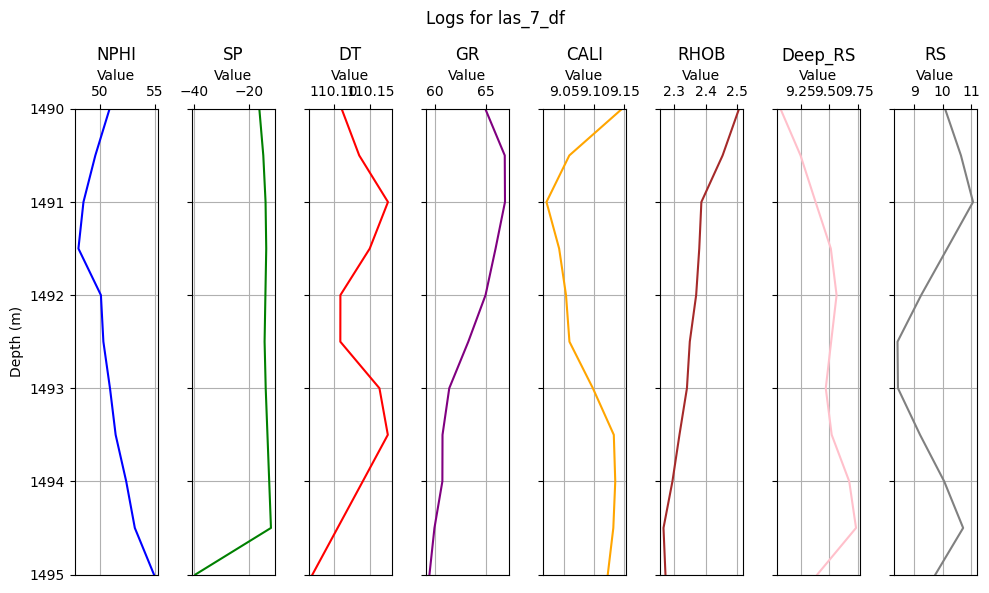

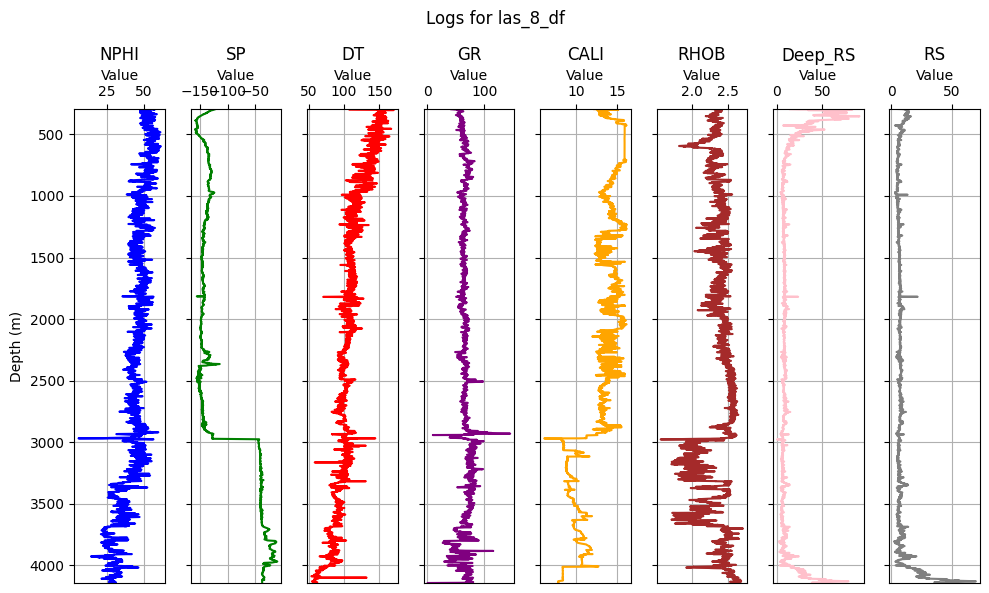

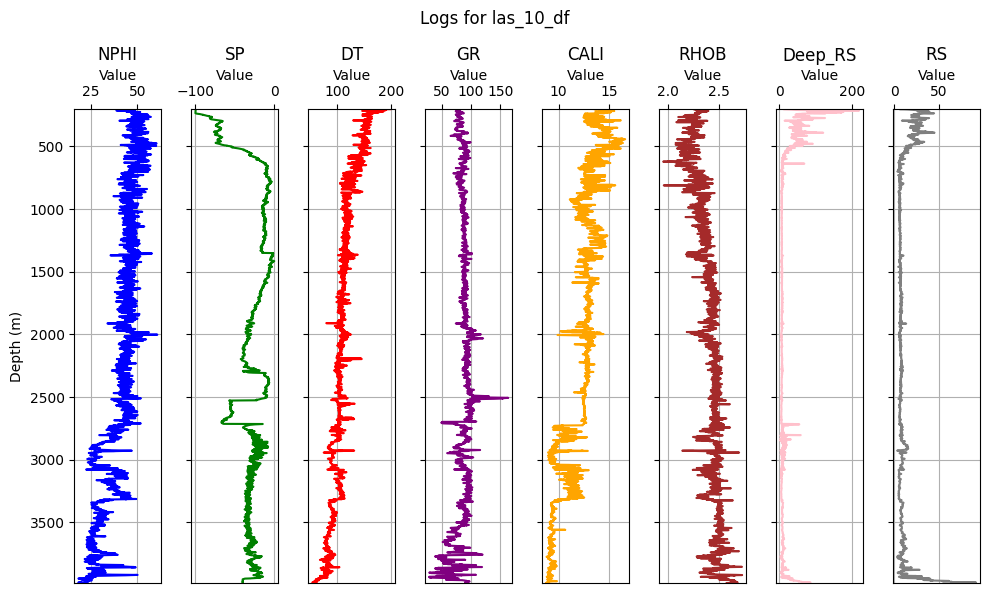

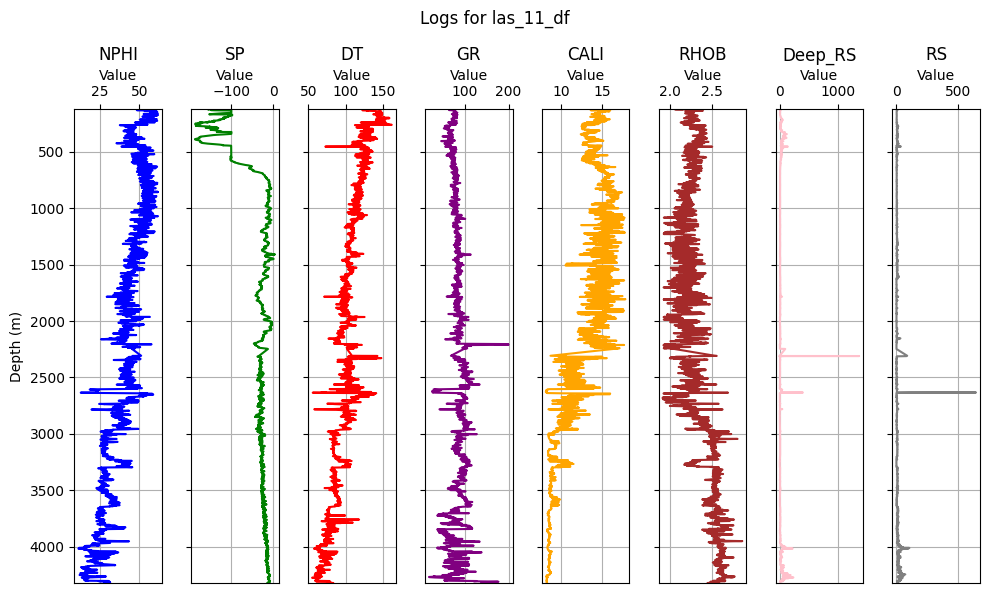

In [181]:
import matplotlib.pyplot as plt

# Split the logs into two groups based on the provided columns in combined_df
logs_to_plot_1 = ['NPHI', 'SP', 'DT', 'GR', 'CALI', 'RHOB', 'Deep_RS', 'RS']

# Assign colors for each log (adjust colors as needed)
log_colors_1 = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray']

# Iterate over each unique source in combined_df
for source in combined_df['source'].unique():
    # Filter the combined DataFrame for the current source
    source_df = combined_df[combined_df['source'] == source]

    # Create a new figure for each source
    fig, axes = plt.subplots(nrows=1, ncols=len(logs_to_plot_1), figsize=(10, 6), sharey=True)
    
    # Plot each log in Group 1
    for i, (log, color) in enumerate(zip(logs_to_plot_1, log_colors_1)):
        if log in source_df.columns:  # Ensure the log exists in the DataFrame
            axes[i].plot(source_df[log], source_df["DEPT"], color=color)
            axes[i].set_title(log)  # Set title for each subplot
            axes[i].grid()

    # Common configuration for all axes in Group 1
    for ax in axes:
        ax.set_ylim(source_df["DEPT"].max(), source_df["DEPT"].min())  # Invert Y axis so depth increases downward
        ax.set_xlabel("Value")
        ax.xaxis.set_label_position("top")
        ax.xaxis.tick_top()

    axes[0].set_ylabel("Depth (m)")

    # Set the title for the entire figure using the source
    plt.suptitle(f"Logs for {source}")
    
    plt.tight_layout()
    plt.show()

Seems that we need to remove outliers/peaks from RS log for las_11_df

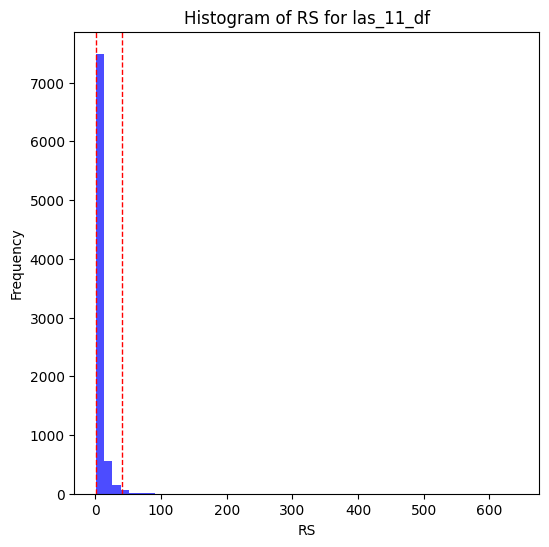

In [182]:
# RS histogram for source = las_11_df showing percentiles 1 and 99

# Filter the combined DataFrame for the source las_11_df

rs_data = combined_df[combined_df['source'] == 'las_11_df']

fig, ax = plt.subplots(figsize=(6, 6))

ax.hist(rs_data['RS'], bins=50, color='blue', alpha=0.7)

ax.set_title("Histogram of RS for las_11_df")
ax.set_xlabel("RS")
ax.set_ylabel("Frequency")

# Add vertical lines for the 1st and 99th percentiles

percentiles = rs_data['RS'].quantile([0.01, 0.99])

ax.axvline(percentiles.iloc[0], color='red', linestyle='dashed', linewidth=1)
ax.axvline(percentiles.iloc[1], color='red', linestyle='dashed', linewidth=1)

plt.show()

In [183]:
# Calculate the 99th percentile value for the 'RS' column where source is 'las_11_df'
rs_99th_percentile = combined_df.loc[combined_df['source'] == 'las_11_df', 'RS'].quantile(0.99)

# Remove rows from combined_df where 'RS' exceeds the 99th percentile for 'las_11_df'
combined_df = combined_df[~((combined_df['source'] == 'las_11_df') & (combined_df['RS'] > rs_99th_percentile))]

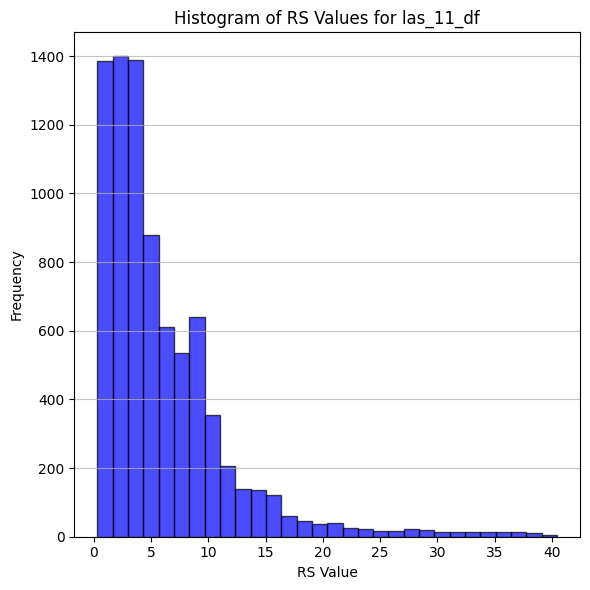

In [185]:
# Filter the DataFrame for source = 'las_11_df'
rs_data = combined_df[combined_df['source'] == 'las_11_df']['RS']

# Plot the histogram
plt.figure(figsize=(6, 6))
plt.hist(rs_data, bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Histogram of RS Values for las_11_df')
plt.xlabel('RS Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

We also should remove wells 6 and 7 as they have too few data

In [186]:
# Remove las_6_df and las_7_df from the combined DataFrame

combined_df = combined_df[~combined_df['source'].isin(['las_6_df', 'las_7_df'])]
combined_df['source'].unique()

array(['las_2_df', 'las_3_df', 'las_4_df', 'las_5_df', 'las_8_df',
       'las_10_df', 'las_11_df'], dtype=object)

In [187]:
combined_df

,DEPT,NPHI,SP,DT,GR,CALI,RHOB,Deep_RS,RS,source
16,1268.0,58.4780,-59.9979,143.6756,61.6657,10.5136,1.8273,4.6447,7.5509,las_2_df
17,1268.5,59.2127,-58.2083,133.0717,64.2292,10.7095,1.7620,10.2542,8.8587,las_2_df
18,1269.0,59.8660,-54.6182,119.9588,64.9464,11.0733,1.7392,30.0874,9.9650,las_2_df
19,1269.5,59.8573,-51.4263,115.2573,64.5629,12.3102,1.7727,49.9206,10.4007,las_2_df
20,1270.0,59.8486,-48.2594,117.9865,63.8467,13.9247,1.8720,355.8461,10.7133,las_2_df
...,...,...,...,...,...,...,...,...,...,...
54571,4320.0,29.8985,-12.4724,79.8472,168.9134,8.2624,2.4812,12.0701,8.2417,las_11_df
54572,4320.5,30.3564,-12.2141,80.6444,171.2971,8.2788,2.4775,12.0084,8.3762,las_11_df
54573,4321.0,30.5920,-14.5468,81.0618,171.2919,8.2741,2.4620,11.9746,8.6290,las_11_df
54574,4321.5,31.0028,-14.8321,81.7074,170.7860,8.2759,2.4533,11.9935,8.9387,las_11_df


# Predicting Continuous Well Measurements